# Analiza danych StatsBomb — Polonia Bytom vs Pogoń Grodzisk Mazowiecki

xG przypisuję do **stanu wyniku bezpośrednio przed strzałem**. Strzał, po którym pada gol, należy więc jeszcze do stanu sprzed gola.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/Polonia Bytom_Pogo  Grodzisk Mazowiecki_4068759.csv"


Ważne: w danych strzały pojawiają się wielokrotnie ze względu na wiersze freeze-frame, więc najpierw deduplikuje eventy po id

In [11]:
events_df = (
    pd.read_csv(DATA_PATH, low_memory=False)
    .drop_duplicates(subset='id')
    .sort_values('index')
)

print(f'Liczba unikalnych zdarzen: {len(events_df)}')

Liczba unikalnych zdarzen: 3232


In [27]:
events_df["event_type_name"].value_counts()

event_type_name
Pass               894
Carries            732
Ball Receipt*      720
Pressure           240
Ball Recovery      103
Duel                62
Clearance           52
Defensive Duel      49
Offensive Duel      49
Block               43
Goal Keeper         37
Shot                34
Loose Ball Duel     34
Foul Committed      28
Foul Won            28
Dribble             28
Dispossessed        20
Dribbled Past       19
Miscontrol          16
Interception         9
Substitution         7
50/50                6
Half Start           4
Half End             4
Tactical Shift       4
Starting XI          2
Shield               2
Player Off           2
Player On            2
Injury Stoppage      1
Bad Behaviour        1
Name: count, dtype: int64

In [26]:
events_df[events_df["event_type_name"] == "Shot"]["id"].nunique() # ilosc unikalnych strzalow

34

## Przypisanie strzałów do stanu meczu

In [13]:
STATES = ('wygrana', 'remis', 'przegrana')
OPPOSITE_STATE = {'wygrana': 'przegrana', 'remis': 'remis', 'przegrana': 'wygrana'}

def get_score_state(team_score, opponent_score):
    if team_score > opponent_score:
        return 'wygrana'
    if team_score < opponent_score:
        return 'przegrana'
    return 'remis'

def assign_shots_to_score_state(events):
    teams = sorted(events.loc[events['team_name'].notna(), 'team_name'].unique())
    score = dict.fromkeys(teams, 0)
    shots_by_state, goals = [], []

    # strzaly tylko z wartoscia xG
    shots = events.loc[
        (events['event_type_name'] == 'Shot') & events['statsbomb_xg'].notna()
    ]

    for event in shots.itertuples(index=False):
        team = event.team_name
        opponent = next(name for name in teams if name != team)
        state = get_score_state(score[team], score[opponent])
        shots_by_state.append({'drużyna': team, 'stan': state, 'xg': event.statsbomb_xg})

        # wynik aktualizuje dopiero po przypisaniu strzalu do stanu meczu
        if event.outcome_name == 'Goal':
            goals.append({
                'minuta': event.minute,
                'drużyna': team,
                'wynik przed golem': f'{score[teams[0]]}:{score[teams[1]]}',
                'stan': state,
            })
            score[team] += 1

    return pd.DataFrame(shots_by_state), pd.DataFrame(goals), teams

In [14]:
shot_df, goals_df, teams = assign_shots_to_score_state(events_df)
goals_df

,minuta,drużyna,wynik przed golem,stan
0,21,Pogoń Grodzisk Mazowiecki,0:0,remis
1,27,Polonia Bytom,1:0,przegrana
2,36,Polonia Bytom,1:1,remis
3,45,Pogoń Grodzisk Mazowiecki,1:2,przegrana


## Różnica xG

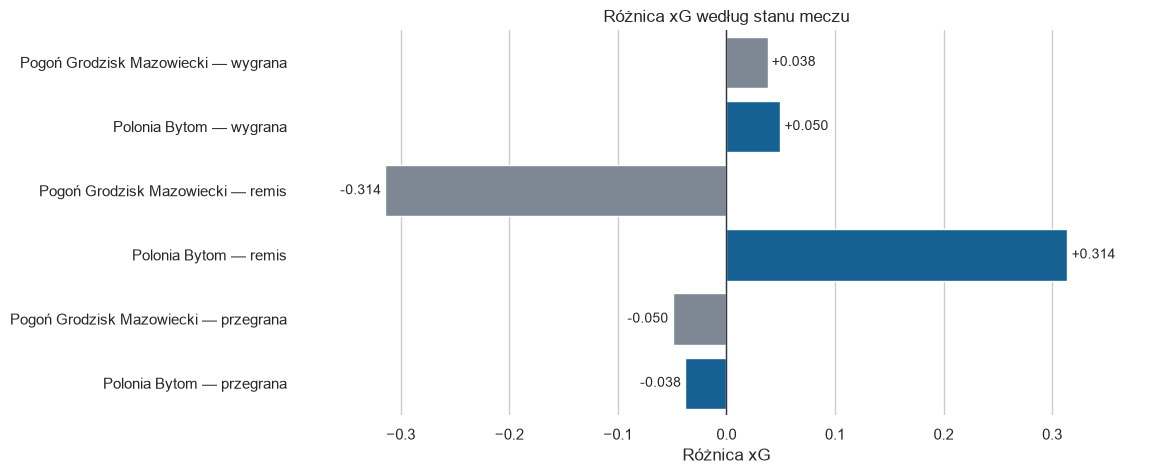

In [15]:
def calculate_xg_difference(shot_df, teams):
    by_state = (
        shot_df.groupby(['drużyna', 'stan'], as_index=False)
        .agg(xG=('xg', 'sum'), strzały=('xg', 'size'))
    )

    # wypelniam tez kombinacje druzyna–stan bez oddanego strzalu
    index = pd.MultiIndex.from_product([teams, STATES], names=['drużyna', 'stan'])
    by_state = by_state.set_index(['drużyna', 'stan']).reindex(index, fill_value=0).reset_index()

    opponent_xg = by_state.rename(columns={
        'drużyna': 'rywal', 'stan': 'stan rywala', 'xG': 'xG rywala'
    })[['rywal', 'stan rywala', 'xG rywala']]

    by_state['rywal'] = by_state['drużyna'].map({teams[0]: teams[1], teams[1]: teams[0]})
    by_state['stan rywala'] = by_state['stan'].map(OPPOSITE_STATE)

    result = by_state.merge(opponent_xg, on=['rywal', 'stan rywala'], how='left')
    result['różnica xG'] = result['xG'] - result['xG rywala']

    return result[['drużyna', 'stan', 'xG', 'xG rywala', 'różnica xG', 'strzały']]

def show_xg_difference_chart(result):
    state_order = {'wygrana': 0, 'remis': 1, 'przegrana': 2}

    plot_data = result.assign(
        _order=result['stan'].map(state_order),
        etykieta=result['drużyna'] + ' — ' + result['stan'],
    ).sort_values(['_order', 'drużyna'])

    sns.set_theme(style='whitegrid')
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(
        data=plot_data, x='różnica xG', y='etykieta', hue='drużyna',
        dodge=False, palette={'Polonia Bytom': '#0065a8', 'Pogoń Grodzisk Mazowiecki': '#7a8799'},
        legend=False, ax=ax,
    )

    max_abs = plot_data['różnica xG'].abs().max()
    ax.axvline(0, color='#2f3640', linewidth=1)
    ax.set(xlim=(-max_abs * 1.25, max_abs * 1.25), xlabel='Różnica xG', ylabel='',
           title='Różnica xG według stanu meczu')

    for container in ax.containers:
        labels = [f'{bar.get_width():+.3f}' for bar in container]
        ax.bar_label(container, labels=labels, padding=3, fontsize=10)

    sns.despine(left=True, bottom=True)
    plt.show()

result = calculate_xg_difference(shot_df, teams)
show_xg_difference_chart(result)


In [17]:
result

,drużyna,stan,xG,xG rywala,różnica xG,strzały
0,Pogoń Grodzisk Mazowiecki,wygrana,0.117319,0.079390,0.037929,2
1,Pogoń Grodzisk Mazowiecki,remis,0.609015,0.923124,-0.314109,10
2,Pogoń Grodzisk Mazowiecki,przegrana,0.016594,0.066237,-0.049642,2
3,Polonia Bytom,wygrana,0.066237,0.016594,0.049642,1
4,Polonia Bytom,remis,0.923124,0.609015,0.314109,17
5,Polonia Bytom,przegrana,0.079390,0.117319,-0.037929,2


In [19]:
result.groupby("drużyna")[["xG", "różnica xG"]].sum()

,xG,różnica xG
drużyna,,
Pogoń Grodzisk Mazowiecki,0.742928,-0.325823
Polonia Bytom,1.068751,0.325823


## Wyniki w skrócie

Łącznie Polonia stworzyła 1,069 xG, a Pogoń 0,743 xG. Największą przewagę xG Polonia wypracowała przy stanie remisowym (+0,314). Przy prowadzeniu również miała dodatni bilans xG, natomiast przy przegrywaniu bilans był lekko ujemny.